In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [5]:
df = pd.concat([X, y], axis=1)

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [9]:
df.num.value_counts()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [10]:
# Convert target to binary before visualizations:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

df.rename(columns={'num': 'target'}, inplace=True)

In [11]:
df.shape

(303, 14)

In [12]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [13]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [14]:
df.dropna(inplace=True) # very few missing values, so dropping them for simplicity

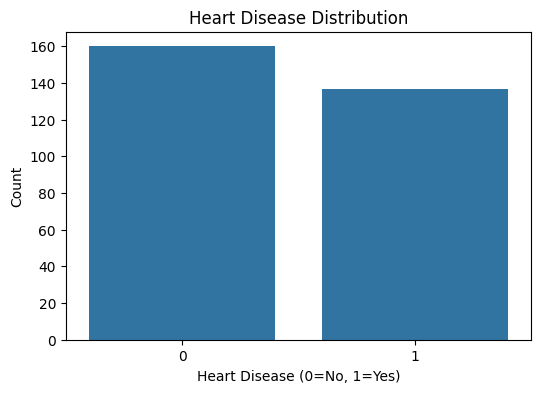

In [15]:
# Target distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0=No, 1=Yes)")
plt.ylabel("Count")

plt.show()

In [16]:
# Also printing percentage distribution
target_counts = df['target'].value_counts()

print(target_counts)

print(
    df['target']
    .value_counts(normalize=True)*100
)

target
0    160
1    137
Name: count, dtype: int64
target
0    53.872054
1    46.127946
Name: proportion, dtype: float64


Target seems to be balanced so no need to be balanced. if not balanced, model can be biased towards class having more value counts.

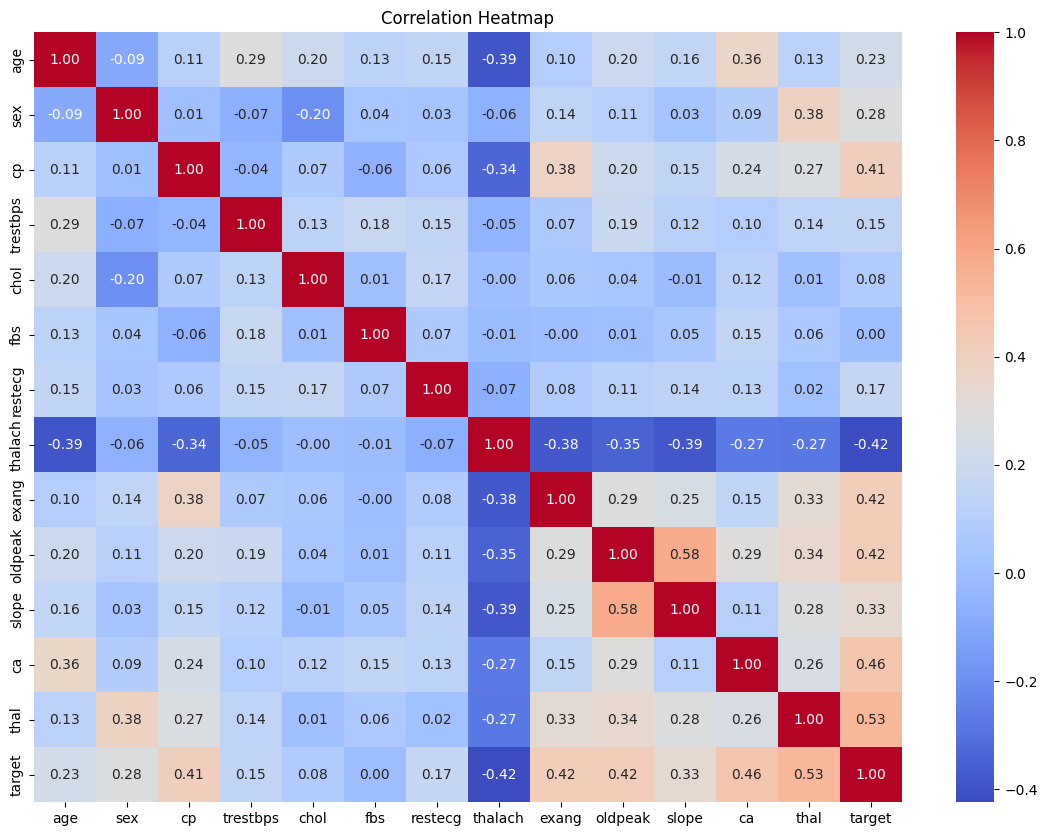

In [17]:
# corrolation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

Correlation analysis revealed that thal (0.53), ca (0.46), exang (0.42), oldpeak (0.42), and cp (0.41) exhibited the strongest positive associations with heart disease presence. Conversely, thalach showed a moderate negative correlation (−0.42), suggesting that higher maximum heart rates are associated with lower disease risk. Features such as fasting blood sugar (fbs) and cholesterol (chol) demonstrated weak relationships with the target variable. Additionally, no severe multicollinearity was observed among predictors, with the highest inter-feature correlation being 0.58 between oldpeak and slope.

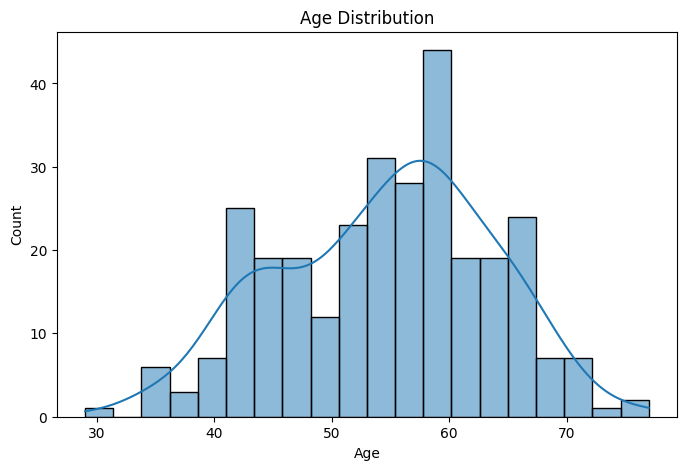

In [18]:
# Age distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=20,
    kde=True,
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.show()

The age distribution was approximately normal, with most patients concentrated between 45 and 65 years of age. The highest frequency was observed around 55–60 years, indicating that middle-aged and older adults constituted the majority of the dataset. No significant outliers were detected, and the age range (approximately 29–77 years) reflects a clinically relevant population for heart disease prediction studies.

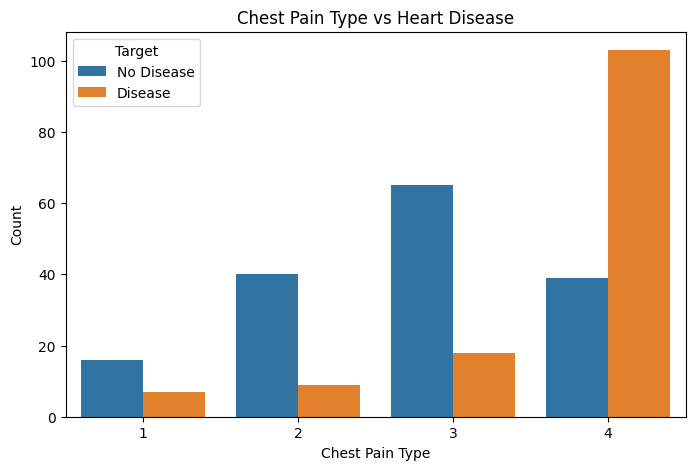

In [19]:
# Chest Pain Type (cp) vs Target
plt.figure(figsize=(8,5))

sns.countplot(
    x='cp',
    hue='target',
    data=df
)

plt.title("Chest Pain Type vs Heart Disease")

plt.xlabel("Chest Pain Type")

plt.ylabel("Count")

plt.legend(
    title='Target',
    labels=['No Disease','Disease']
)

plt.show()


Analysis of chest pain types revealed a strong association with heart disease status. Patients classified as asymptomatic (cp = 4) exhibited the highest prevalence of heart disease, whereas typical angina (cp = 1), atypical angina (cp = 2), and non-anginal pain (cp = 3) were more frequently observed among individuals without heart disease. These findings suggest that chest pain type is an important predictive feature for heart disease diagnosis.